# Segmentación de cultivos con AnySat (congelado) sobre PASTIS-R

Se entrena un segmentador basado en AnySat (Astruc et al., 2024), un modelo fundacional para datos de observación de la Tierra. AnySat se usa congelado, como extractor de características, y solo se entrena una cabeza lineal que las proyecta a las clases de cultivo; el entrenamiento es barato porque el grueso de los pesos no se actualiza.

Este cuaderno corre de forma independiente (en paralelo con el de U-Net) y deja sus artefactos en carpetas del Drive compartido para el reporte: la tabla de métricas, la figura de la matriz de confusión y el modelo entrenado.

In [1]:
!rm -rf /content/agrosat-copilot

## Datos y métricas

PASTIS-R entrega parches Sentinel-2 multitemporales de 128x128, que aquí se reescalan a 256. Las etiquetas tienen 20 clases: fondo, 18 tipos de cultivo y una clase void que se descarta en la pérdida y en las métricas. El split de entrenamiento y validación usa los folds oficiales del dataset, espacialmente disjuntos. Se reportan mIoU, F1-macro y exactitud a nivel de píxel en dos esquemas: las 18 clases planas y los 6 grupos agronómicos HCAT (cereales, oleaginosas, tubérculos, leguminosas, leñosos y otros), siendo este último el comparable con el baseline del avance anterior.

In [1]:
# Setup del entorno. En Colab se monta Drive (donde vive el dataset) y se
# instalan las dependencias que no vienen por defecto; en local no hace falta.
import os, sys, subprocess
from pathlib import Path

_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# En Colab el repo no esta presente: se clona una vez en /content/agrosat-copilot.
if _IN_COLAB:
    from getpass import getpass
    _repo_dir = '/content/agrosat-copilot'
    _branch = 'main'
    _repo = 'github.com/ArthurZizumbo/agrosat-copilot.git'
    if not Path(_repo_dir, 'pyproject.toml').is_file():
        _rc = os.system(f'git clone --branch {_branch} --depth 1 https://{_repo} {_repo_dir}')
        if _rc != 0:  # repo privado: pide token (no se guarda en el notebook)
            _tok = getpass('GitHub token (repo privado): ')
            os.system(f'git clone --branch {_branch} --depth 1 https://{_tok}@{_repo} {_repo_dir}')

# El codigo no vive en Drive: se localiza el repo por su pyproject.toml.
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break
else:
    raise RuntimeError('No se encontro el repo agrosat-copilot (pyproject.toml). '
                       'Clonalo en /content/agrosat-copilot o sincronizalo desde VS Code.')

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'segmentation-models-pytorch', 'structlog', 'typer', 'polars', 'mlflow'], check=False)

print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')

Mounted at /content/drive
repo: /content/agrosat-copilot | colab: True | drive: /content/drive/MyDrive/Integrador/


In [2]:
# Configuracion de la corrida.
import torch

MODEL = 'anysat'
SUFFIX = '_fast'          # sufijo de artefactos (para correr variantes en paralelo)
REDUCTION = 'none'    # 'median' (U-Net) o 'none' (AnySat, serie temporal)
# El dataset vive en Drive; en local se usa la copia del repo.
PASTIS_ROOT = Path((shared_folder_path + 'data/PASTIS-R') if shared_folder_path
                   else 'data/PASTIS-R')
# Carpetas de artefactos en Drive (claras para citarlas en el reporte):
#   reports/segmentation/metrics      -> parquet de metricas por modelo
#   reports/segmentation/figures      -> PNG de la matriz de confusion
#   reports/segmentation/checkpoints  -> modelo final + checkpoint reanudable
SEG_DIR = Path((shared_folder_path if shared_folder_path else '') + 'reports/segmentation')
METRICS_DIR = SEG_DIR / 'metrics'
FIGURES_DIR = SEG_DIR / 'figures'
CHECKPOINT_DIR = SEG_DIR / 'checkpoints_fast'
for _d in (METRICS_DIR, FIGURES_DIR, CHECKPOINT_DIR):
    _d.mkdir(parents=True, exist_ok=True)
COMPARISON_PATH = METRICS_DIR / f'model_comparison_avance4_{MODEL}_fast.parquet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TARGET_SIZE = 64
SUBSET = 400            # 0 = todos; reducir si la sesion es corta
EPOCHS = 30
BATCH = 1
MLFLOW_URI = 'file:./mlruns'
# Por defecto se lee directo de Drive (sin copiar). Si vas a entrenar muchas epocas y
# preferis acelerar, pone COPY_TO_LOCAL=True (copia una vez al disco efimero).
COPY_TO_LOCAL = False
# Leyendo de Drive, num_workers=0 va mas rapido (el FUSE de Drive penaliza la
# concurrencia). Con el dataset copiado a local conviene subirlo a 2-4.
NUM_WORKERS = 0

print('modelo:', MODEL, '| device:', DEVICE, '| batch:', BATCH)
print('PASTIS_ROOT:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
print('artefactos en:', SEG_DIR)

modelo: anysat | device: cuda | batch: 1
PASTIS_ROOT: /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True
artefactos en: /content/drive/MyDrive/Integrador/reports/segmentation


## Lectura del dataset

Por defecto el dataset se lee directo desde Drive, sin copiar nada: así se evita la espera inicial y no se pierde trabajo si la sesión se reinicia. El loader abre cada parche con un solo acceso a disco (no relee el archivo de metadatos en cada paso) y el DataLoader usa varios procesos en paralelo. Si preferís acelerar, poné `COPY_TO_LOCAL = True` en la celda anterior para copiar una vez al disco local de la sesión.

In [3]:
# Copia del dataset de Drive al disco local, con barra de progreso.
import shutil, time

def copy_pastis_to_local(src_root, dst_root,
                         subdirs=('DATA_S2', 'ANNOTATIONS'),
                         files=('metadata.geojson', 'NORM_S2_patch.json')):
    src_root, dst_root = Path(src_root), Path(dst_root)
    dst_root.mkdir(parents=True, exist_ok=True)
    todo = []
    for sub in subdirs:
        for f in sorted((src_root / sub).glob('*')):
            if f.is_file():
                todo.append((f, dst_root / sub / f.name))
    for fname in files:
        sp = src_root / fname
        if sp.is_file():
            todo.append((sp, dst_root / fname))
    if not todo:
        raise FileNotFoundError(f'No se hallaron DATA_S2/ANNOTATIONS en {src_root}')
    total_bytes = sum(s.stat().st_size for s, _ in todo)
    try:
        from tqdm.auto import tqdm
        bar = tqdm(total=total_bytes, unit='B', unit_scale=True, desc='Copiando PASTIS')
    except Exception:
        bar = None
    t0 = time.time()
    for i, (src, dst) in enumerate(todo, 1):
        dst.parent.mkdir(parents=True, exist_ok=True)
        # Salta el archivo si ya esta copiado con el mismo tamano.
        if not (dst.exists() and dst.stat().st_size == src.stat().st_size):
            shutil.copy2(src, dst)
        if bar is not None:
            bar.update(src.stat().st_size)
        elif i % 200 == 0:
            print(f'  {i}/{len(todo)} archivos...')
    if bar is not None:
        bar.close()
    print(f'Listo: {len(todo)} archivos ({total_bytes / 1e9:.1f} GB) en {time.time() - t0:.0f}s -> {dst_root}')
    return dst_root

if _IN_COLAB and COPY_TO_LOCAL:
    PASTIS_ROOT = copy_pastis_to_local(PASTIS_ROOT, '/content/PASTIS-R')
    print('PASTIS_ROOT (local):', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
else:
    print('Lectura directa desde:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())

Lectura directa desde: /content/drive/MyDrive/Integrador/data/PASTIS-R | exists: True


In [4]:
# Split en los folds oficiales de PASTIS (espacialmente disjuntos).
from ml.ingest.pastis_dataset import pastis_fold_split

split = pastis_fold_split(PASTIS_ROOT, train_folds=(1, 2, 3), val_folds=(4,), test_folds=(5,))
print({k: len(v) for k, v in split.items()})

{'train': 1455, 'val': 482, 'test': 496}


## Entrenamiento

AnySat se descarga la primera vez desde su repositorio (torch.hub). El entrenamiento guarda un checkpoint por época en Drive; si la sesión se reinicia, al volver a ejecutar esta celda se reanuda desde la última época completada.

In [7]:
# Carga de AnySat (torch.hub) y entrenamiento de la cabeza lineal.
from ml.train.train_segmentation import run_training
from ml.models.anysat_wrapper import load_anysat_encoder

_ = load_anysat_encoder()  # descarga y valida los pesos antes de entrenar
result = run_training(
    model=MODEL, epochs=EPOCHS, batch_size=BATCH, target_size=TARGET_SIZE,
    subset=SUBSET, device=DEVICE, root=PASTIS_ROOT, mlflow_uri=MLFLOW_URI,
    comparison_path=COMPARISON_PATH, num_workers=NUM_WORKERS, output_dir=CHECKPOINT_DIR,
)
result

Downloading: "https://github.com/gastruc/anysat/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://huggingface.co/g-astruc/AnySat/resolve/main/models/AnySat.pth" to /root/.cache/torch/hub/checkpoints/AnySat.pth


100%|██████████| 480M/480M [00:01<00:00, 385MB/s] 


2026-06-01 14:03:09 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat


Using cache found in /root/.cache/torch/hub/gastruc_anysat_main


2026-06-01 14:03:11 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat
2026-06-01 14:03:40 [info     ] segmentation_resume            f1_macro=0.5715745276933225 f1_macro_grouped=0.7203306494307198 miou=0.4459350711729844 miou_grouped=0.5912615368211289 model=anysat pixel_accuracy=0.7500923931920805 pixel_accuracy_grouped=0.7173933520065439 start_epoch=30
2026-06-01 14:03:40 [info     ] segmentation_train_start       device=cuda epochs=30 model=anysat n_total=125936187 n_train=400 n_trainable=30740 n_val=200


2026/06/01 14:03:40 INFO mlflow.tracking.fluent: Experiment with name 'agrosat-segmentation' does not exist. Creating a new experiment.


2026-06-01 14:03:40 [warning  ] dvc file ausente, data_version=untracked path=/content/drive/MyDrive/Integrador/data/PASTIS-R.dvc
2026-06-01 14:03:40 [info     ] mlflow_run_started             code_version=1fb9beb8e2a35d54c1478155567eb553cff3acb3 data_version=/content/drive/MyDrive/Integrador/data/PASTIS-R@untracked experiment=agrosat-segmentation run_id=1adcb6e797f14af38e1e1b885ba1cfa1 run_name=seg-anysat-pastis-v1 tracking_uri=file:./mlruns
2026-06-01 14:03:51 [info     ] segmentation_train_done        f1_macro=0.5715745276933225 f1_macro_grouped=0.7203306494307198 miou=0.4459350711729844 miou_grouped=0.5912615368211289 model=anysat pixel_accuracy=0.7500923931920805 pixel_accuracy_grouped=0.7173933520065439


{'model': 'anysat',
 'miou': 0.4459350711729844,
 'f1_macro': 0.5715745276933225,
 'pixel_accuracy': 0.7500923931920805,
 'miou_grouped': 0.5912615368211289,
 'f1_macro_grouped': 0.7203306494307198,
 'pixel_accuracy_grouped': 0.7173933520065439,
 'train_time_s': 2.0404344209999863,
 'checkpoint_path': '/content/drive/MyDrive/Integrador/reports/segmentation/checkpoints_fast/anysat_pastis.pt'}

## Métricas

Tabla de métricas de este modelo sobre el fold de validación, en los dos esquemas (18 clases y 6 grupos HCAT). Se guarda en `reports/segmentation/metrics/`; el notebook integrador la une con la del otro modelo para la comparativa final. Las columnas con sufijo `grouped` corresponden a los 6 grupos (el fondo no entra en esas métricas).

In [5]:
import polars as pl

table = pl.read_parquet(COMPARISON_PATH)
cols = ['model', 'miou_grouped', 'f1_macro_grouped', 'pixel_accuracy_grouped',
        'miou', 'f1_macro', 'pixel_accuracy', 'train_time_s', 'epochs']
table.select([c for c in cols if c in table.columns])

model,miou_grouped,f1_macro_grouped,pixel_accuracy_grouped,miou,f1_macro,pixel_accuracy,train_time_s,epochs
str,f64,f64,f64,f64,f64,f64,f64,i64
"""anysat""",0.591262,0.720331,0.717393,0.445935,0.571575,0.750092,3561.698268,30


Se repite el efecto de la agrupación que ya se vio en la U-Net. A 18 clases el modelo da mIoU 0.45, F1-macro 0.57 y exactitud 0.75; sobre los 6 grupos HCAT sube a 0.59 de mIoU y 0.72 de F1-macro, y la exactitud queda parecida (0.72). Conviene recordar que aquí solo se entrenó la cabeza lineal sobre el encoder de AnySat congelado, así que el resultado viene de las features pre-entrenadas. El salto de 0.45 a 0.59 al agrupar es de nuevo la confusión entre cereales parecidos que desaparece.

## Matriz de confusión

Recall por clase a nivel de píxel sobre el fold de validación, sin contar la clase void. La figura se guarda en `reports/segmentation/figures/` para el reporte.

Using cache found in /root/.cache/torch/hub/gastruc_anysat_main


2026-06-01 14:04:00 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat
Figura guardada en: /content/drive/MyDrive/Integrador/reports/segmentation/figures/confusion_anysat_fast.png


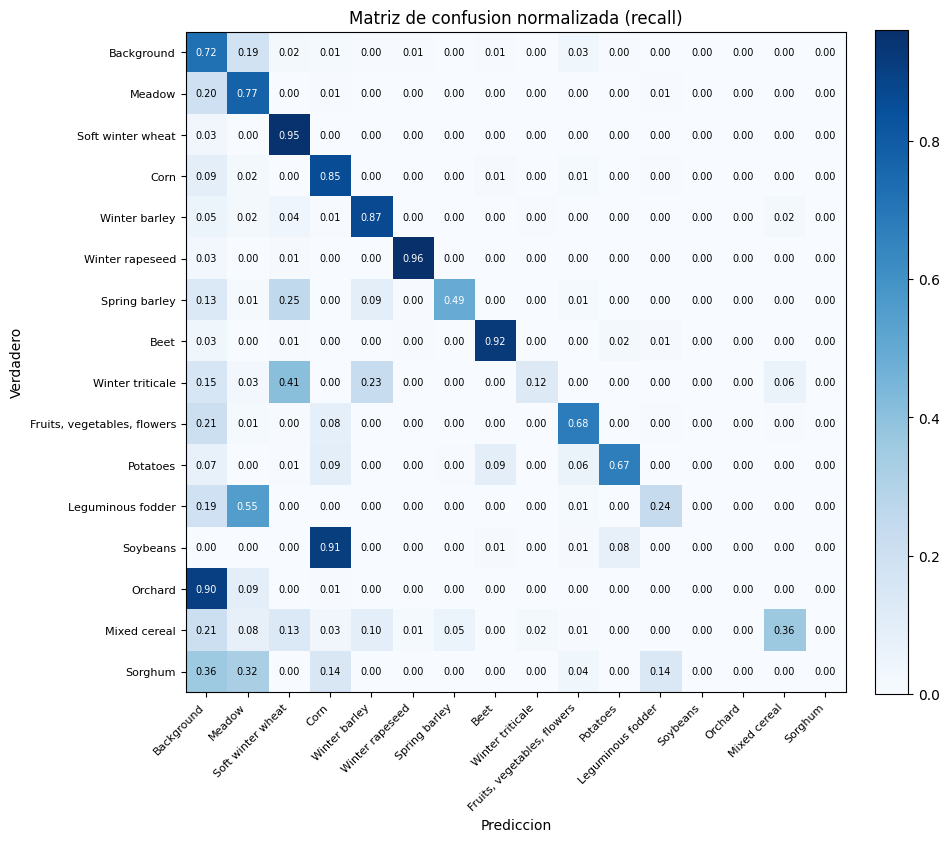

In [8]:
# Matriz de confusion a nivel de pixel; se guarda como PNG en Drive.
import torch
from torch.utils.data import DataLoader
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats, PASTIS_IGNORE_INDEX
from ml.ingest.pastis_loader import PASTIS_CLASS_MAP
from ml.eval.dense_metrics import dense_confusion_figure
from ml.models.anysat_wrapper import AnySatSegmenter

def confusion_figure(model_name, reduction, build_fn, ckpt, max_patches=40):
    norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
    val_ids = split['val'][:max_patches]
    ds = PASTISDataset(val_ids, root=PASTIS_ROOT, target_size=TARGET_SIZE,
                       temporal_reduction=reduction, norm=norm)
    loader = DataLoader(ds, batch_size=2)
    model = build_fn().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for b in loader:
            img = b['image'].to(DEVICE)
            out = model(img) if model_name == 'unet' else model(img, b['dates'].to(DEVICE))
            preds.append(out.argmax(1).cpu().reshape(-1))
            tgts.append(b['semantic'].reshape(-1))
    return dense_confusion_figure(torch.cat(preds), torch.cat(tgts),
                                  class_names=PASTIS_CLASS_MAP, ignore_index=PASTIS_IGNORE_INDEX)

fig = confusion_figure(MODEL, 'none', lambda: AnySatSegmenter(20, target_size=TARGET_SIZE),
                       result['checkpoint_path'])
_fig_path = FIGURES_DIR / f'confusion_{MODEL}_fast.png'
fig.savefig(_fig_path, bbox_inches='tight', dpi=120)
print('Figura guardada en:', _fig_path)
fig

La matriz está normalizada por fila, así que cada celda es el recall de la clase. Frente a la U-Net la diagonal está más limpia en las clases comunes y la confusión entre los cereales de invierno (trigo blando, duro, cebada, triticale) se nota menos. Tiene sentido, porque AnySat usa toda la serie temporal y distingue cultivos que en una sola fecha se ven iguales pero crecen en momentos distintos. Las clases con pocos ejemplos siguen con recall bajo.

## IoU por clase

IoU de cada clase sobre el fold de validación, ordenado de menor a mayor, con la línea del mIoU. Identifica qué cultivos resuelve bien el modelo y cuáles le cuestan. Carga el modelo guardado (no re-entrena) y guarda el PNG en `figures/`.

Using cache found in /root/.cache/torch/hub/gastruc_anysat_main


2026-06-01 14:09:26 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat
guardado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/per_class_iou_anysat_fast.png


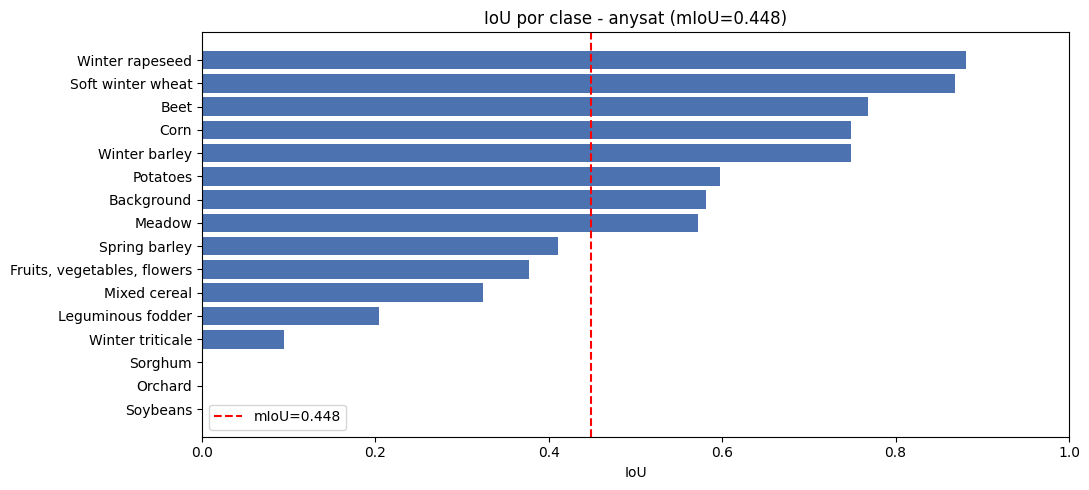

In [ ]:
# IoU por clase (carga el modelo guardado, no re-entrena).
import torch, numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats
from ml.ingest.pastis_loader import PASTIS_CLASS_MAP
from ml.eval.dense_metrics import DenseConfusionAccumulator
from ml.models.anysat_wrapper import AnySatSegmenter

_norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
_ds = PASTISDataset(split['val'][:40], root=PASTIS_ROOT, target_size=TARGET_SIZE,
                    temporal_reduction=REDUCTION, norm=_norm)
_loader = DataLoader(_ds, batch_size=2)
_model = AnySatSegmenter(20, target_size=TARGET_SIZE).to(DEVICE)
_model.load_state_dict(torch.load(result['checkpoint_path'], map_location=DEVICE))
_model.eval()
_acc = DenseConfusionAccumulator(20, ignore_index=19, device=str(DEVICE))
with torch.no_grad():
    for _b in _loader:
        _img = _b['image'].to(DEVICE)
        _out = _model(_img) if MODEL == 'unet' else _model(_img, _b['dates'].to(DEVICE))
        _acc.update(_out.argmax(1), _b['semantic'].to(DEVICE))
_iou = _acc.per_class_iou()
_items = sorted(_iou.items(), key=lambda kv: kv[1])
_names = [PASTIS_CLASS_MAP.get(c, str(c)) for c, _ in _items]
_vals = [v for _, v in _items]
_miou = float(np.mean(_vals)) if _vals else 0.0
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(_names, _vals, color='#4C72B0')
ax.axvline(_miou, color='red', linestyle='--', label=f'mIoU={_miou:.3f}')
ax.set_xlim(0, 1); ax.set_xlabel('IoU'); ax.legend()
ax.set_title(f'IoU por clase - {MODEL} (mIoU={_miou:.3f})')
fig.tight_layout()
_p = FIGURES_DIR / f'per_class_iou_{MODEL}{SUFFIX}.png'
fig.savefig(_p, bbox_inches='tight', dpi=120); print('guardado:', _p)
fig

El IoU por clase va de menor a mayor. Igual que siempre, las clases con más superficie quedan por encima del promedio y los cultivos raros cerca de cero. La diferencia con la U-Net es que hay menos clases pegadas a cero: varias que la CNN dejaba en cero aquí ya tienen algo de IoU, y por eso el mIoU a 18 clases (0.45) termina casi al doble del de la U-Net (0.24).

## Comparación visual (RGB / verdad / predicción)

Para unas parcelas de validación: la imagen Sentinel-2 en color (bandas B04/B03/B02), la máscara verdadera y la predicción del modelo, con el mismo colormap de clases. Es la vista cualitativa que muestra de un vistazo qué tan bien delinea las parcelas.

Using cache found in /root/.cache/torch/hub/gastruc_anysat_main


2026-06-01 14:09:49 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat
guardado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/samples_anysat_fast.png


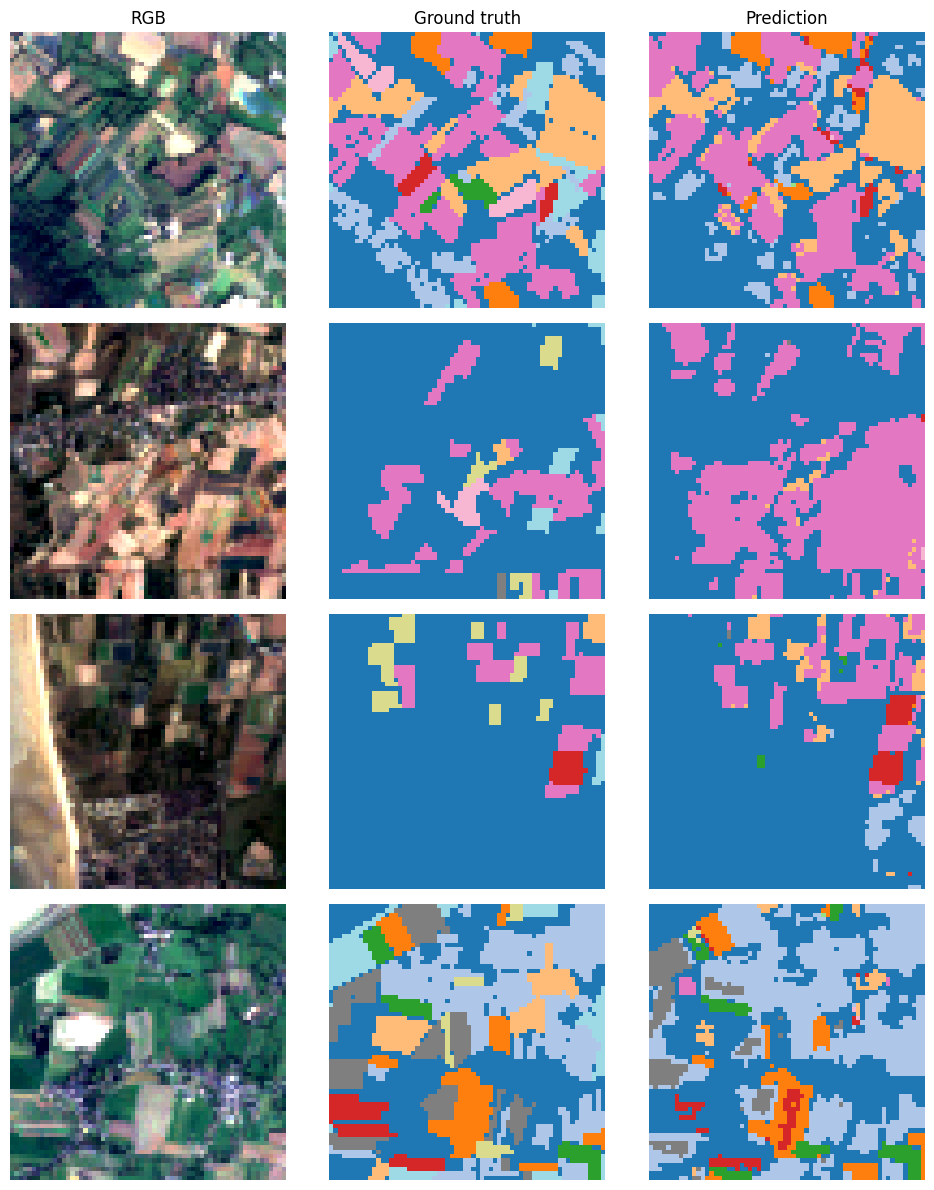

In [ ]:
# RGB | ground truth | prediccion para N parcelas (carga el modelo guardado).
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats
from ml.ingest.pastis_loader import PASTIS_S2_BANDS
from ml.models.anysat_wrapper import AnySatSegmenter

_norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
_ds = PASTISDataset(split['val'][:4], root=PASTIS_ROOT, target_size=TARGET_SIZE,
                    temporal_reduction=REDUCTION, norm=_norm)
_model = AnySatSegmenter(20, target_size=TARGET_SIZE).to(DEVICE)
_model.load_state_dict(torch.load(result['checkpoint_path'], map_location=DEVICE))
_model.eval()
_cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, 20)))
_ri, _gi, _bi = (PASTIS_S2_BANDS.index(x) for x in ('B04', 'B03', 'B02'))
_n = len(_ds)
fig, axes = plt.subplots(_n, 3, figsize=(10, 3 * _n))
axes = np.atleast_2d(axes)
with torch.no_grad():
    for _k in range(_n):
        _it = _ds[_k]
        _img = _it['image']
        _arr = _img if _img.dim() == 3 else _img.median(0).values
        _rgb = _arr[[_ri, _gi, _bi]].permute(1, 2, 0).numpy()
        _lo, _hi = np.percentile(_rgb, 2), np.percentile(_rgb, 98)
        _rgb = np.clip((_rgb - _lo) / (_hi - _lo + 1e-6), 0, 1)
        _x = _img.unsqueeze(0).to(DEVICE)
        _out = (_model(_x) if MODEL == 'unet'
                else _model(_x, _it['dates'].unsqueeze(0).to(DEVICE)))
        _pred = _out.argmax(1)[0].cpu().numpy()
        _gt = _it['semantic'].numpy()
        axes[_k, 0].imshow(_rgb)
        axes[_k, 1].imshow(_gt, cmap=_cmap, vmin=0, vmax=19)
        axes[_k, 2].imshow(_pred, cmap=_cmap, vmin=0, vmax=19)
        for _j, _t in enumerate(('RGB', 'Ground truth', 'Prediction')):
            axes[_k, _j].axis('off')
            if _k == 0:
                axes[_k, _j].set_title(_t)
fig.tight_layout()
_p = FIGURES_DIR / f'samples_{MODEL}{SUFFIX}.png'
fig.savefig(_p, bbox_inches='tight', dpi=120); print('guardado:', _p)
fig

En las imágenes AnySat acierta los cultivos dominantes y la forma general de las parcelas. Esta corrida fue a 64 px por el consumo de memoria del encoder, así que los bordes salen más gruesos y las parcelas pequeñas se mezclan con la vecina. Aun así, en las clases frecuentes coincide bien con la verdad de campo, lo que encaja con que el mIoU sea mejor que el de la U-Net a pesar de la menor resolución.

## Curvas de entrenamiento

Evolución del loss de entrenamiento y del mIoU de validación por época, a partir del historial que el entrenamiento guarda en `metrics/history_<modelo>.parquet`. Sirve para ver convergencia y si el modelo se estanca. Si el modelo se entrenó con una versión anterior sin historial, esta celda lo avisa.

guardado: /content/drive/MyDrive/Integrador/reports/segmentation/figures/curves_anysat_fast.png


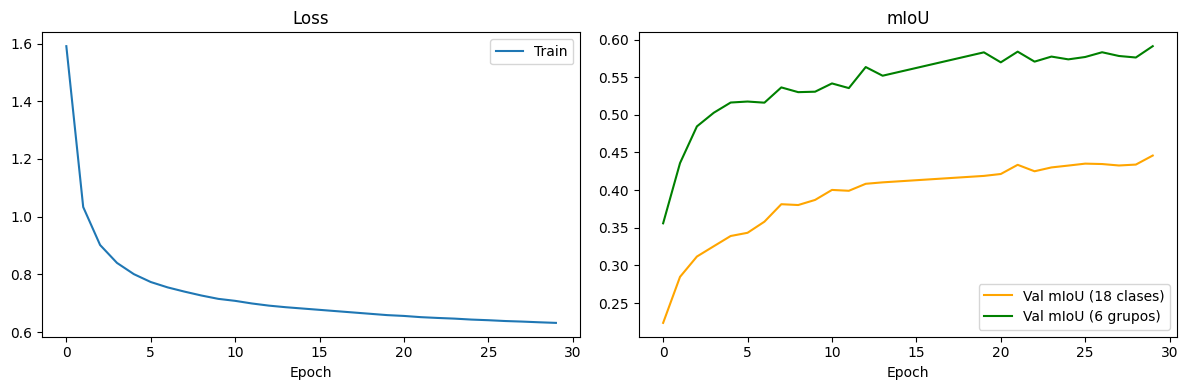

In [11]:
# Curvas de loss y mIoU por epoca (desde el historial guardado).
import polars as pl, matplotlib.pyplot as plt

_hp = METRICS_DIR / f'history_{MODEL}{SUFFIX}.parquet'
if _hp.exists():
    _h = pl.read_parquet(_hp).sort('epoch')
    _ep = _h['epoch'].to_list()
    fig, (_a1, _a2) = plt.subplots(1, 2, figsize=(12, 4))
    _a1.plot(_ep, _h['train_loss'].to_list(), label='Train')
    _a1.set_title('Loss'); _a1.set_xlabel('Epoch'); _a1.legend()
    _a2.plot(_ep, _h['miou'].to_list(), label='Val mIoU (18 clases)', color='orange')
    if 'miou_grouped' in _h.columns:
        _a2.plot(_ep, _h['miou_grouped'].to_list(), label='Val mIoU (6 grupos)', color='green')
    _a2.set_title('mIoU'); _a2.set_xlabel('Epoch'); _a2.legend()
    fig.tight_layout()
    _p = FIGURES_DIR / f'curves_{MODEL}{SUFFIX}.png'
    fig.savefig(_p, bbox_inches='tight', dpi=120); print('guardado:', _p)
    display(fig)
else:
    print('No hay history parquet en', _hp)
    print('El modelo se entreno con una version sin historial; las curvas no estan')
    print('disponibles para esta corrida (re-entrenar con el codigo nuevo las genera).')

## Conclusiones

AnySat con el encoder congelado y solo una cabeza lineal entrenable da, en validación, mIoU 0.45, F1-macro 0.57 y pixel-accuracy 0.75 sobre las 18 clases. Sobre los 6 grupos HCAT, que es lo comparable con el baseline del Avance 3, sube a mIoU 0.59, F1-macro 0.72 y pixel-accuracy 0.72.

Comparado con la U-Net ResNet-50 bajo el mismo protocolo, AnySat queda por encima en casi todo: el mIoU a 18 clases pasa de 0.24 a 0.45 y el de 6 grupos de 0.45 a 0.59. Y eso entrenando solo unos 30 mil parámetros de la cabeza, frente a los millones de la U-Net, y a 64 px en lugar de 256. La ventaja está en que AnySat mira toda la serie temporal y parte de representaciones ya entrenadas, mientras la U-Net trabaja sobre un composite de una sola fecha.

Como en la U-Net, la exactitud alta junto a un F1-macro más bajo dice que resuelve bien las clases comunes y peor las raras. La subida al agrupar (0.45 a 0.59) sigue siendo la confusión entre cultivos hermanos, que aquí pesa menos porque la información temporal ayuda a separarlos. Y todo salió barato: unos 59 min en una L4 ajustando nada más la cabeza.

Para el Avance 4, AnySat queda mejor posicionado que la U-Net y apunta al top-2 junto con los modelos temporales (U-TAE, TSViT). Falta cerrar la comparación con el resto de las arquitecturas y, sobre los dos mejores, hacer el ajuste de hiperparámetros para elegir el modelo individual final.

## Ajuste fino del top-2 (Optuna)

Como este modelo entra al top-2, se afinan sus hiperparametros con Optuna (>=30 trials) maximizando el mIoU de los 6 grupos HCAT. Cada trial entrena pocas epocas sobre un subset reducido y usa pruning para cortar los trials que arrancan mal. El resumen se exporta a `reports/segmentation/metrics/tuning_<modelo>.parquet`, que el integrador `Avance4.Equipo17` levanta y muestra.

In [ ]:
# Ajuste fino con Optuna sobre el top-2 (>=30 trials). Busca lr y weight_decay
# (y batch_size en la U-Net) maximizando el mIoU de los 6 grupos HCAT. Cada trial
# entrena pocas epocas sobre un subset reducido, con pruning para abortar los malos.
import optuna
import polars as pl
from ml.train.train_segmentation import run_training

TUNE_TRIALS = 30
TUNE_EPOCHS = 8
TUNE_SUBSET = SUBSET if SUBSET else 300   # subset reducido: 30 trials deben ser viables
# Artefactos temporales del tuning, aislados de los del modelo final (no los pisan ni
# los recoge el integrador, que solo lee metrics/model_comparison_* y metrics/tuning_*).
TUNE_DIR = SEG_DIR / 'tuning_tmp'
TUNE_DIR.mkdir(parents=True, exist_ok=True)
TUNE_TMP_COMPARISON = TUNE_DIR / f'model_comparison_avance4_{MODEL}.parquet'

def _objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    # En AnySat el batch queda fijo (a 64 px un batch mayor desborda la GPU);
    # en la U-Net 2D si se explora.
    bs = BATCH if MODEL == 'anysat' else trial.suggest_categorical('batch_size', [4, 8, 16])

    def _report(epoch, metrics):
        trial.report(metrics['miou_grouped'], step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    res = run_training(
        model=MODEL, epochs=TUNE_EPOCHS, batch_size=bs, lr=lr, weight_decay=wd,
        target_size=TARGET_SIZE, subset=TUNE_SUBSET, device=DEVICE, root=PASTIS_ROOT,
        mlflow_uri=MLFLOW_URI, num_workers=NUM_WORKERS,
        output_dir=TUNE_DIR, comparison_path=TUNE_TMP_COMPARISON,
        resume=False, on_epoch=_report,
    )
    return res['miou_grouped']

study = optuna.create_study(
    direction='maximize', study_name=f'tune-{MODEL}',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study.optimize(_objective, n_trials=TUNE_TRIALS)

# Resumen de todos los trials -> metrics/tuning_<modelo>.parquet (lo consume el Avance4).
_rows = [{
    'model': MODEL,
    'trial': t.number,
    'state': t.state.name,
    'lr': t.params.get('lr'),
    'weight_decay': t.params.get('weight_decay'),
    'batch_size': t.params.get('batch_size', BATCH),
    'miou_grouped': t.value,
} for t in study.trials]
tuning = pl.DataFrame(_rows)
TUNING_PARQUET = METRICS_DIR / f'tuning_{MODEL}.parquet'
tuning.write_parquet(TUNING_PARQUET)
print('mejores hiperparametros:', study.best_params)
print('mejor mIoU (6 grupos):', round(study.best_value, 4), '| guardado en', TUNING_PARQUET)
tuning.sort('miou_grouped', descending=True, nulls_last=True)